In [1]:
import matplotlib.pyplot as plt
import pyart
import numpy as np
import numpy.ma as ma
from datetime import datetime, timedelta
import nexradaws
import os
import metpy
from ungridded_section_spin import quality_control_spin
import pickle
from netCDF4 import Dataset
import metpy.interpolate
from RAP_Archive import get_RAP_data
from metpy.units import units
from metpy.interpolate import interpolate_to_points
from metpy.calc import wind_components
from scipy.ndimage import shift
import netCDF4
from pyproj import Geod


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
#ncfile = Dataset('SPORK_NC/SPORK_GRIDCAL2020523KFDR.nc')
#ncfile = Dataset('SPORK_NC/SPORK_RERUN2023622KFTG.nc')
#ncfile = Dataset('D:/SPORK_AC/SPORK_AC201659KOAX.nc')
#ncfile = Dataset('D:/SPORK_AC/SPORK_AC201933KMXX.nc')
#ncfile = Dataset('SPORK_NC/SPORK_ONE2016031600KILX.nc')
#ncfile = Dataset('SPORK_NC/SPORK_ONE2019060901KGLD.nc')
#ncfile = Dataset('SPORK_NC/SPORK_ONE2014042523KMHX.nc')
#ncfile = Dataset('SPORK_NC/SPORK_ONE2016052223KMAF.nc')
#ncfile = Dataset('SPORK_NC/SPORK_ONE2018121821KATX.nc')
#ncfile = Dataset('SPORK_NC/SPORK_ONE2023040103KIND.nc')
#ncfile = Dataset('SPORK_NC/SPORK_ONE2014072721KMRX.nc')
ncfile = Dataset('SPORK_NC/SPORK_ONE2015122322KNQA.nc')


ref = ncfile.variables['REFL'][:]
zdr = ncfile.variables['ZDR'][:]
zdrd = ncfile.variables['ZDRD'][:]
kdp = ncfile.variables['KDP'][:]
cc = ncfile.variables['CC'][:]
times = ncfile.variables['Times'][:]
lon_st = ncfile.variables['Lons'][:]
lat_st = ncfile.variables['Lats'][:]
rot = ncfile.variables['ROT'][:]
vel = ncfile.variables['VEL'][:]
azim = ncfile.variables['azim'][:]

zdrd[zdrd==0]=np.nan

In [3]:
xr = np.arange(0,150,1)

Text(0.5, 1.0, '2015-12-23 22:10:00')

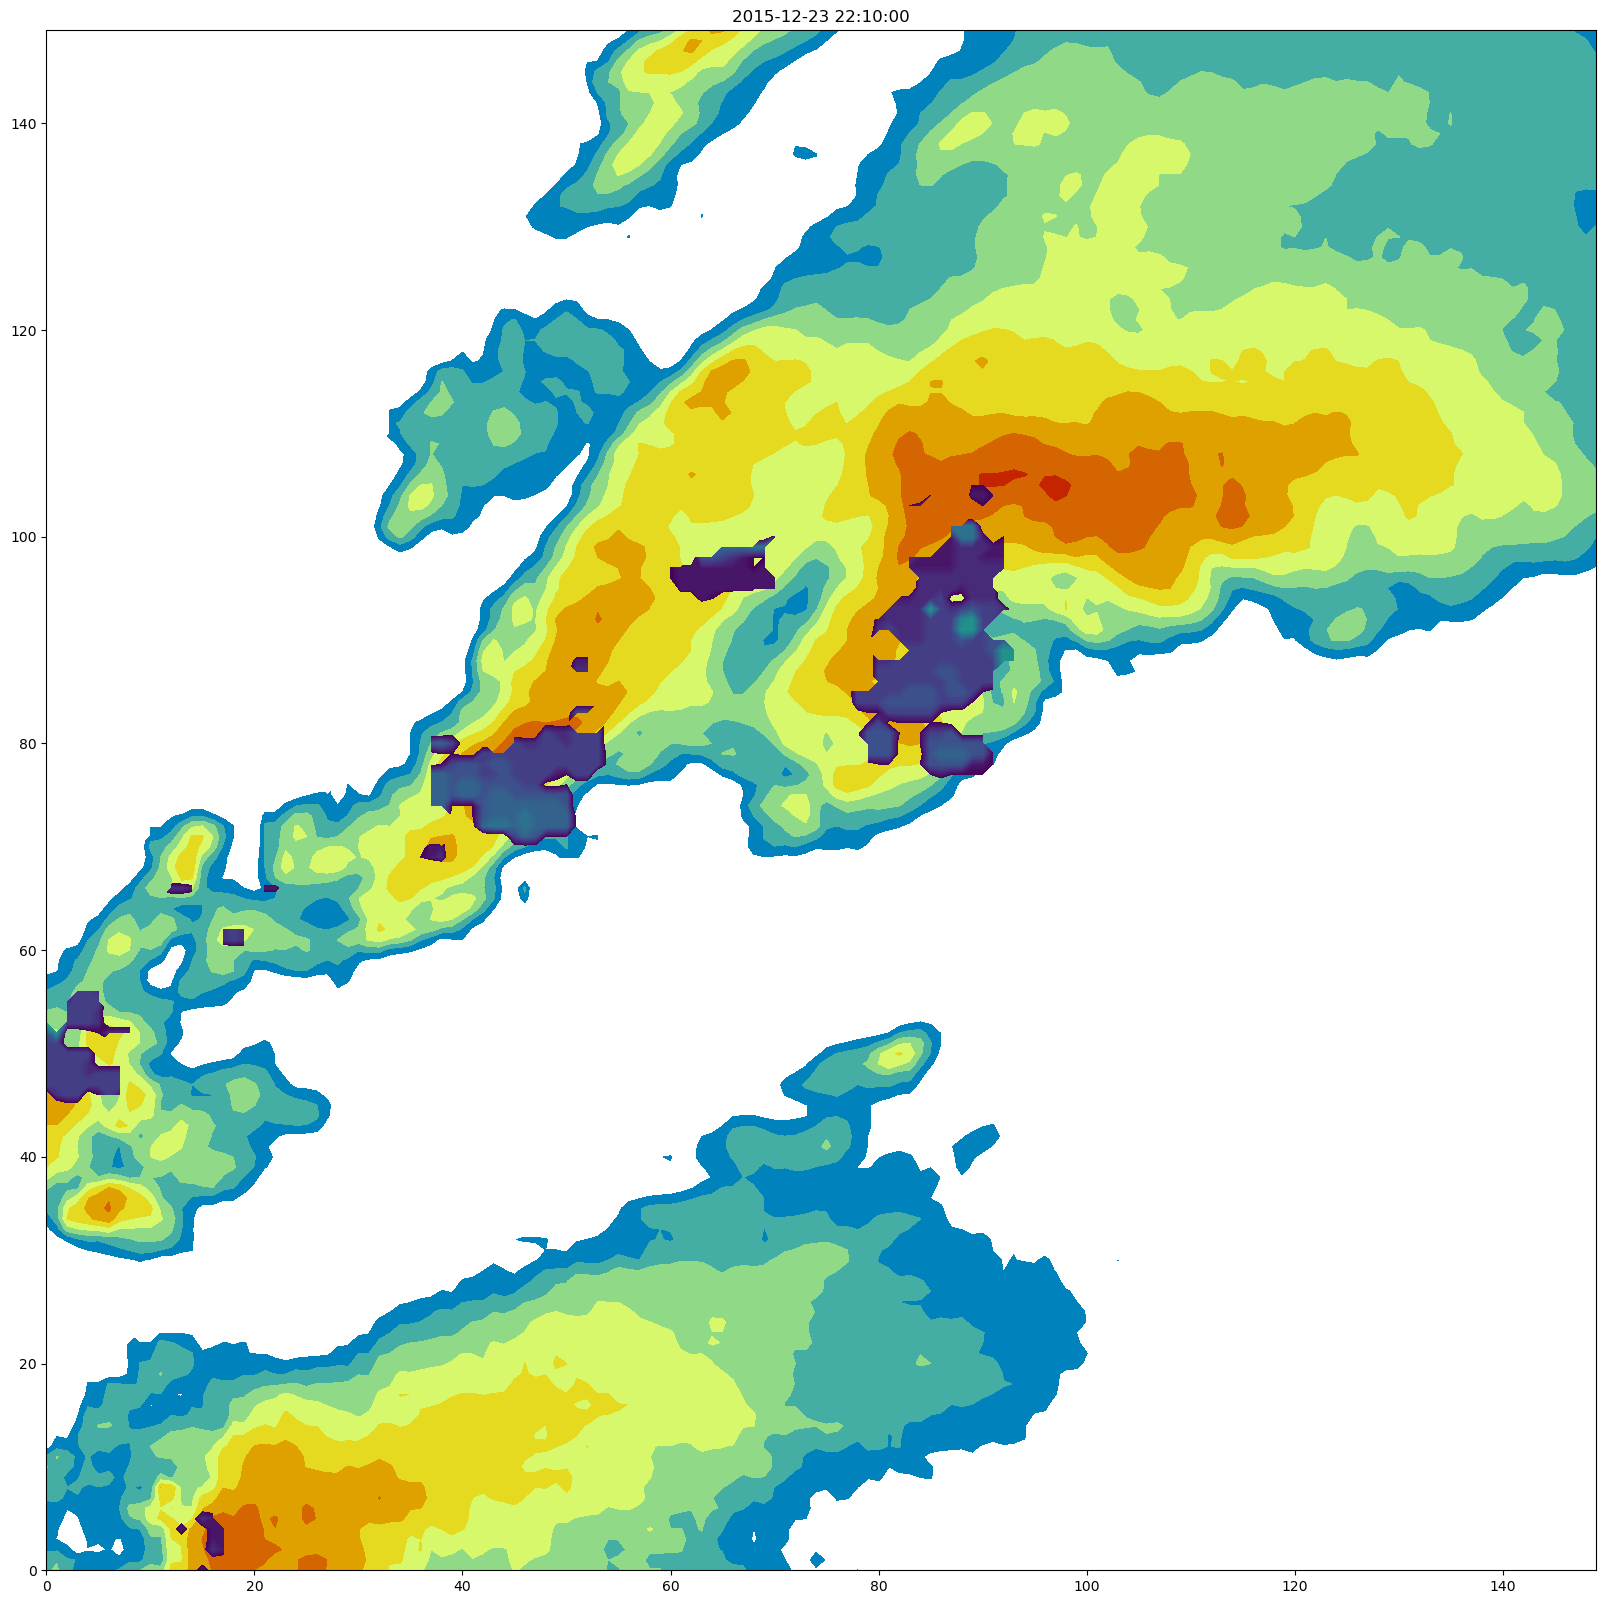

In [4]:
#time=8
lev=4
plt.figure(1, figsize=(20,20))
plt.contourf(xr,xr,ref[lev,:,:],np.arange(20,70,5),cmap=pyart.graph.cmweather.cm_colorblind.HomeyerRainbow)
plt.contourf(xr,xr,zdrd[:,:],np.arange(4,20,0.25),cmap=plt.cm.viridis)

plt.title(str(datetime.fromtimestamp(times[0])))

Text(0.5, 1.0, '2015-12-23 22:10:00')

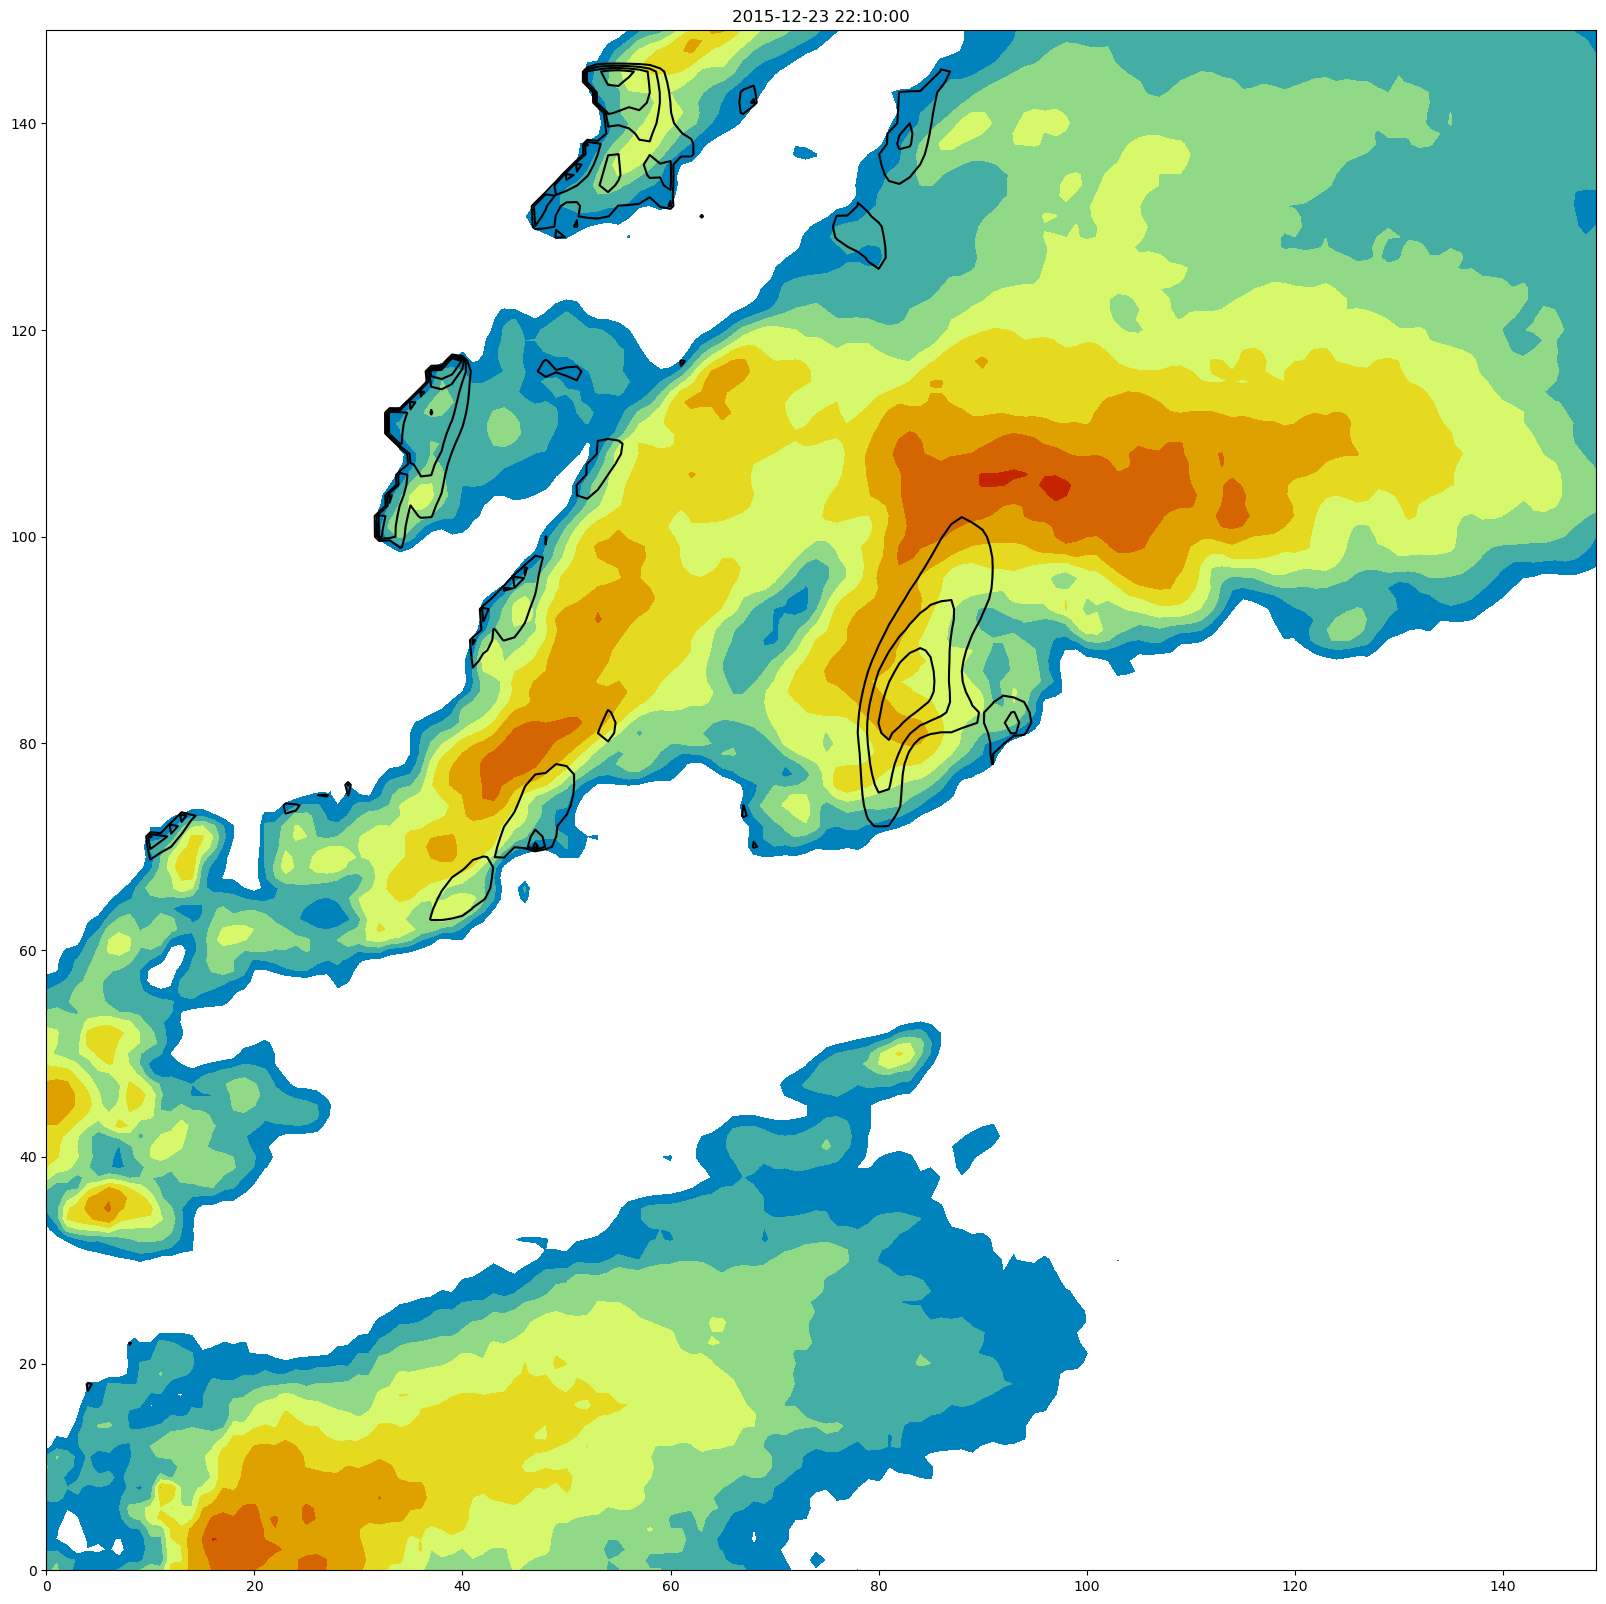

In [5]:
#time=8
lev=4
plt.figure(1, figsize=(20,20))
plt.contourf(xr,xr,ref[lev,:,:],np.arange(20,70,5),cmap=pyart.graph.cmweather.cm_colorblind.HomeyerRainbow)
plt.contour(xr,xr,rot[4,:,:],np.arange(0.002,0.010,0.002),colors='k')
# plt.contour(xr,xr,rot[12,:,:],np.arange(0.002,0.010,0.002),colors='r')
# plt.contour(xr,xr,rot[20,:,:],np.arange(0.002,0.010,0.002),colors='b')
# plt.contour(xr,xr,rot[28,:,:],np.arange(0.002,0.010,0.002),colors='grey')

plt.title(str(datetime.fromtimestamp(times[0])))

Text(0.5, 1.0, '2015-12-23 22:10:00')

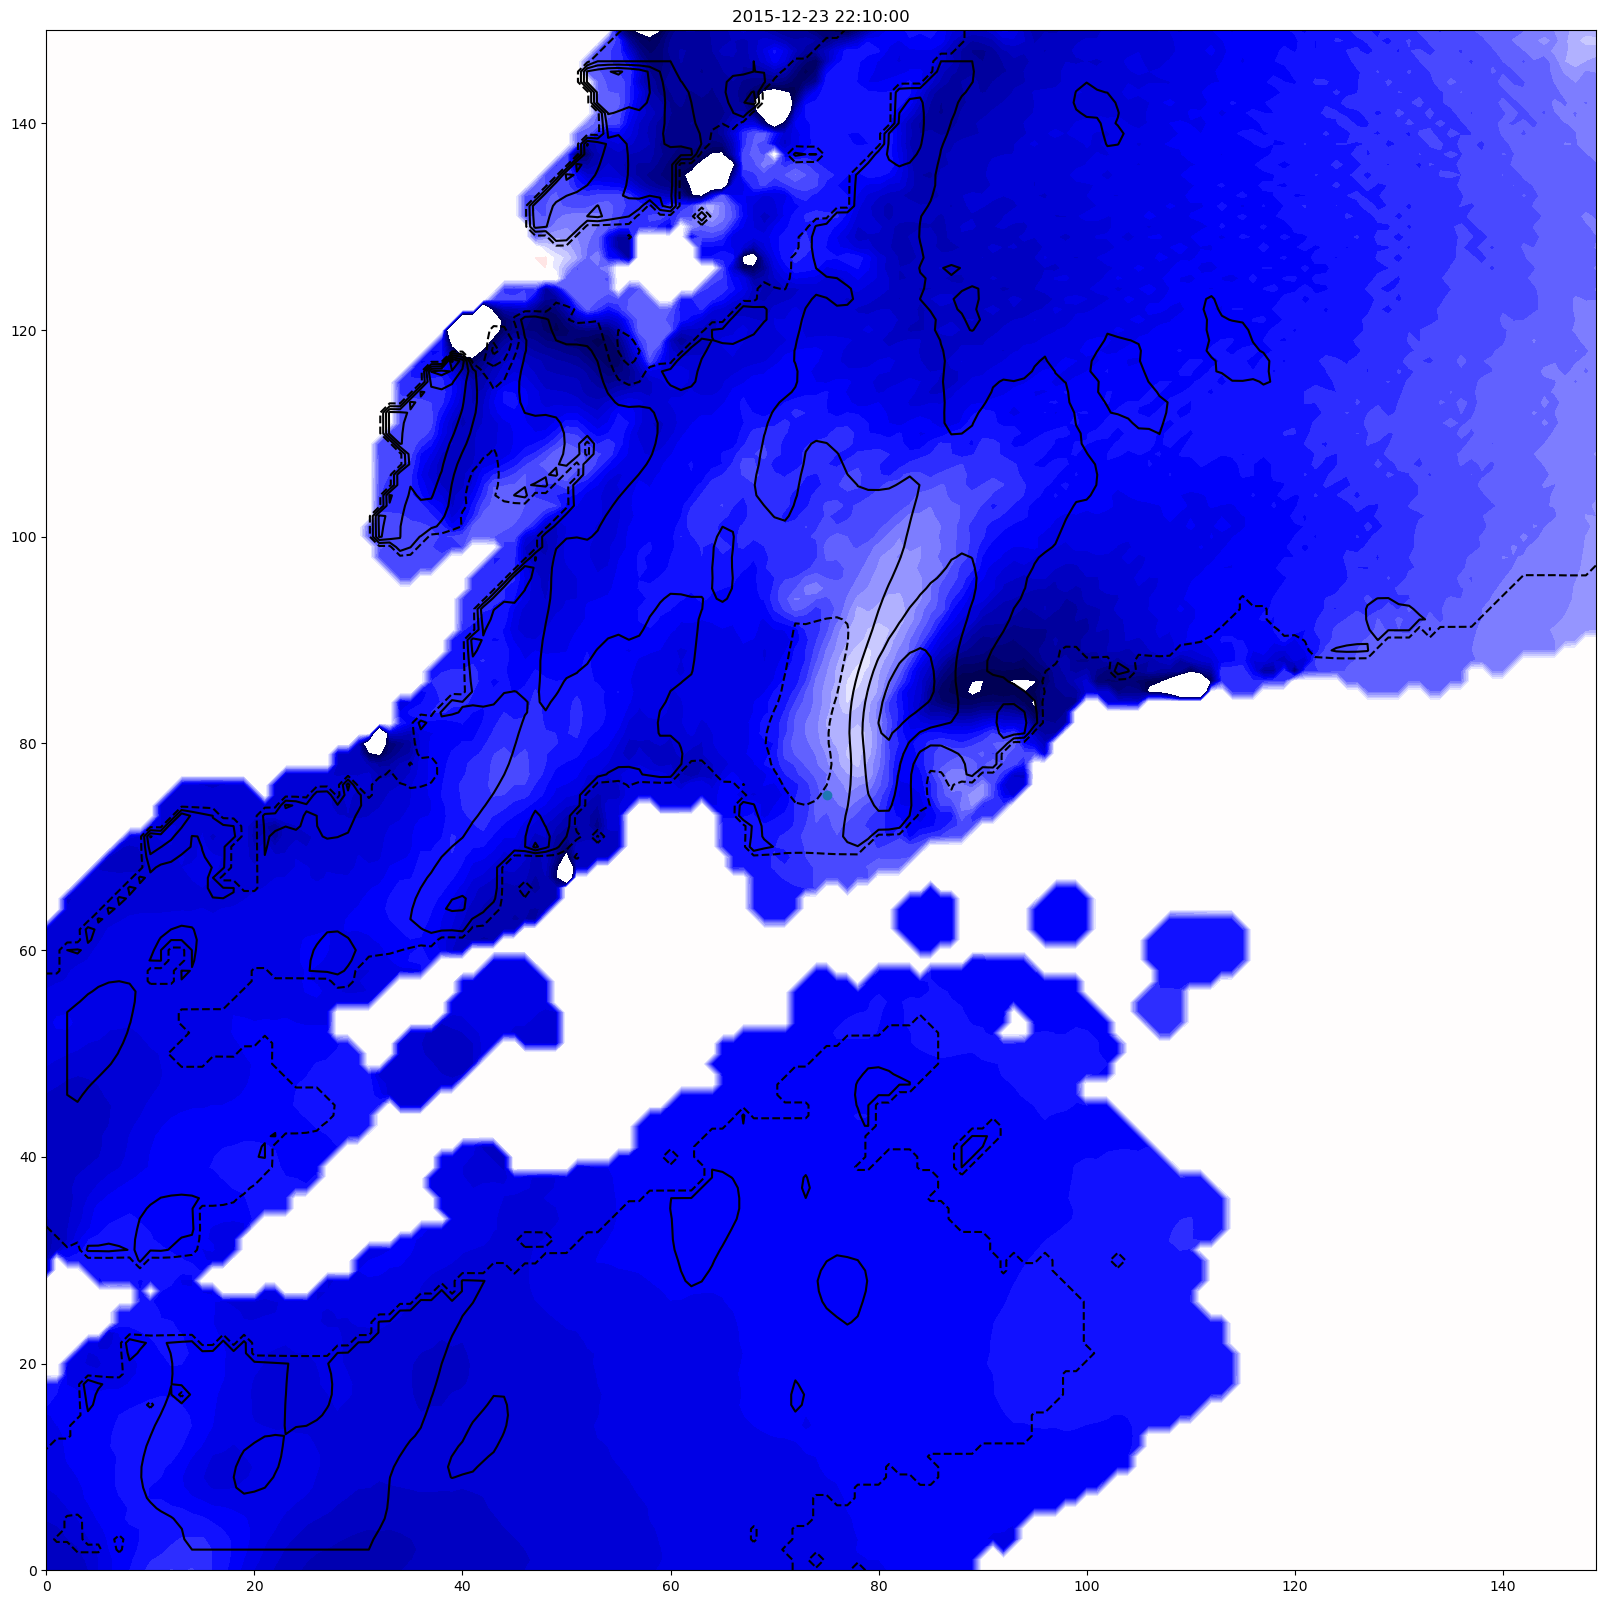

In [6]:
#time=8
lev=4
plt.figure(1, figsize=(20,20))
plt.contourf(xr,xr,vel[lev,:,:],np.arange(-40,40,2),cmap=plt.cm.seismic)
#plt.contour(xr,xr,rot[lev,:,:],np.arange(0.002,0.010,0.002),colors='k')
plt.contour(xr,xr,rot[lev,:,:],colors='k')
plt.scatter(xr[75], xr[75])
# plt.contour(xr,xr,rot[12,:,:],np.arange(0.002,0.010,0.002),colors='r')
# plt.contour(xr,xr,rot[20,:,:],np.arange(0.002,0.010,0.002),colors='b')
# plt.contour(xr,xr,rot[28,:,:],np.arange(0.002,0.010,0.002),colors='grey')

plt.title(str(datetime.fromtimestamp(times[0])))

In [7]:
print(np.nanmax(vel[4,:,:]))

0.3008884787559509


In [8]:
print(lon_st.shape)
g = Geod(ellps='sphere')

(150, 150)


In [9]:
lon_c = np.copy(lon_st)
lat_c = np.copy(lat_st)
lon_c[:] = -101.70
lat_c[:] = 39.37

In [10]:
distance_kdp_zdr = g.inv(lon_st, lat_st, lon_c, lat_c)

In [11]:
print(distance_kdp_zdr[0].shape)

(150, 150)


In [12]:
print(np.max(lon_st), np.min(lon_st))
print(np.max(lat_st), np.min(lat_st))

-89.29861887023986 -90.12138112976012
34.93724572996814 34.26207424888958


In [13]:
azim2=np.copy(azim)
azim2[azim2<0]=360-azim2[azim2<0]*-1

In [14]:
print(np.max(azim))
print(np.min(azim))

296.49631027877024
220.80839317013692


Text(0.5, 1.0, '2015-12-23 22:10:00')

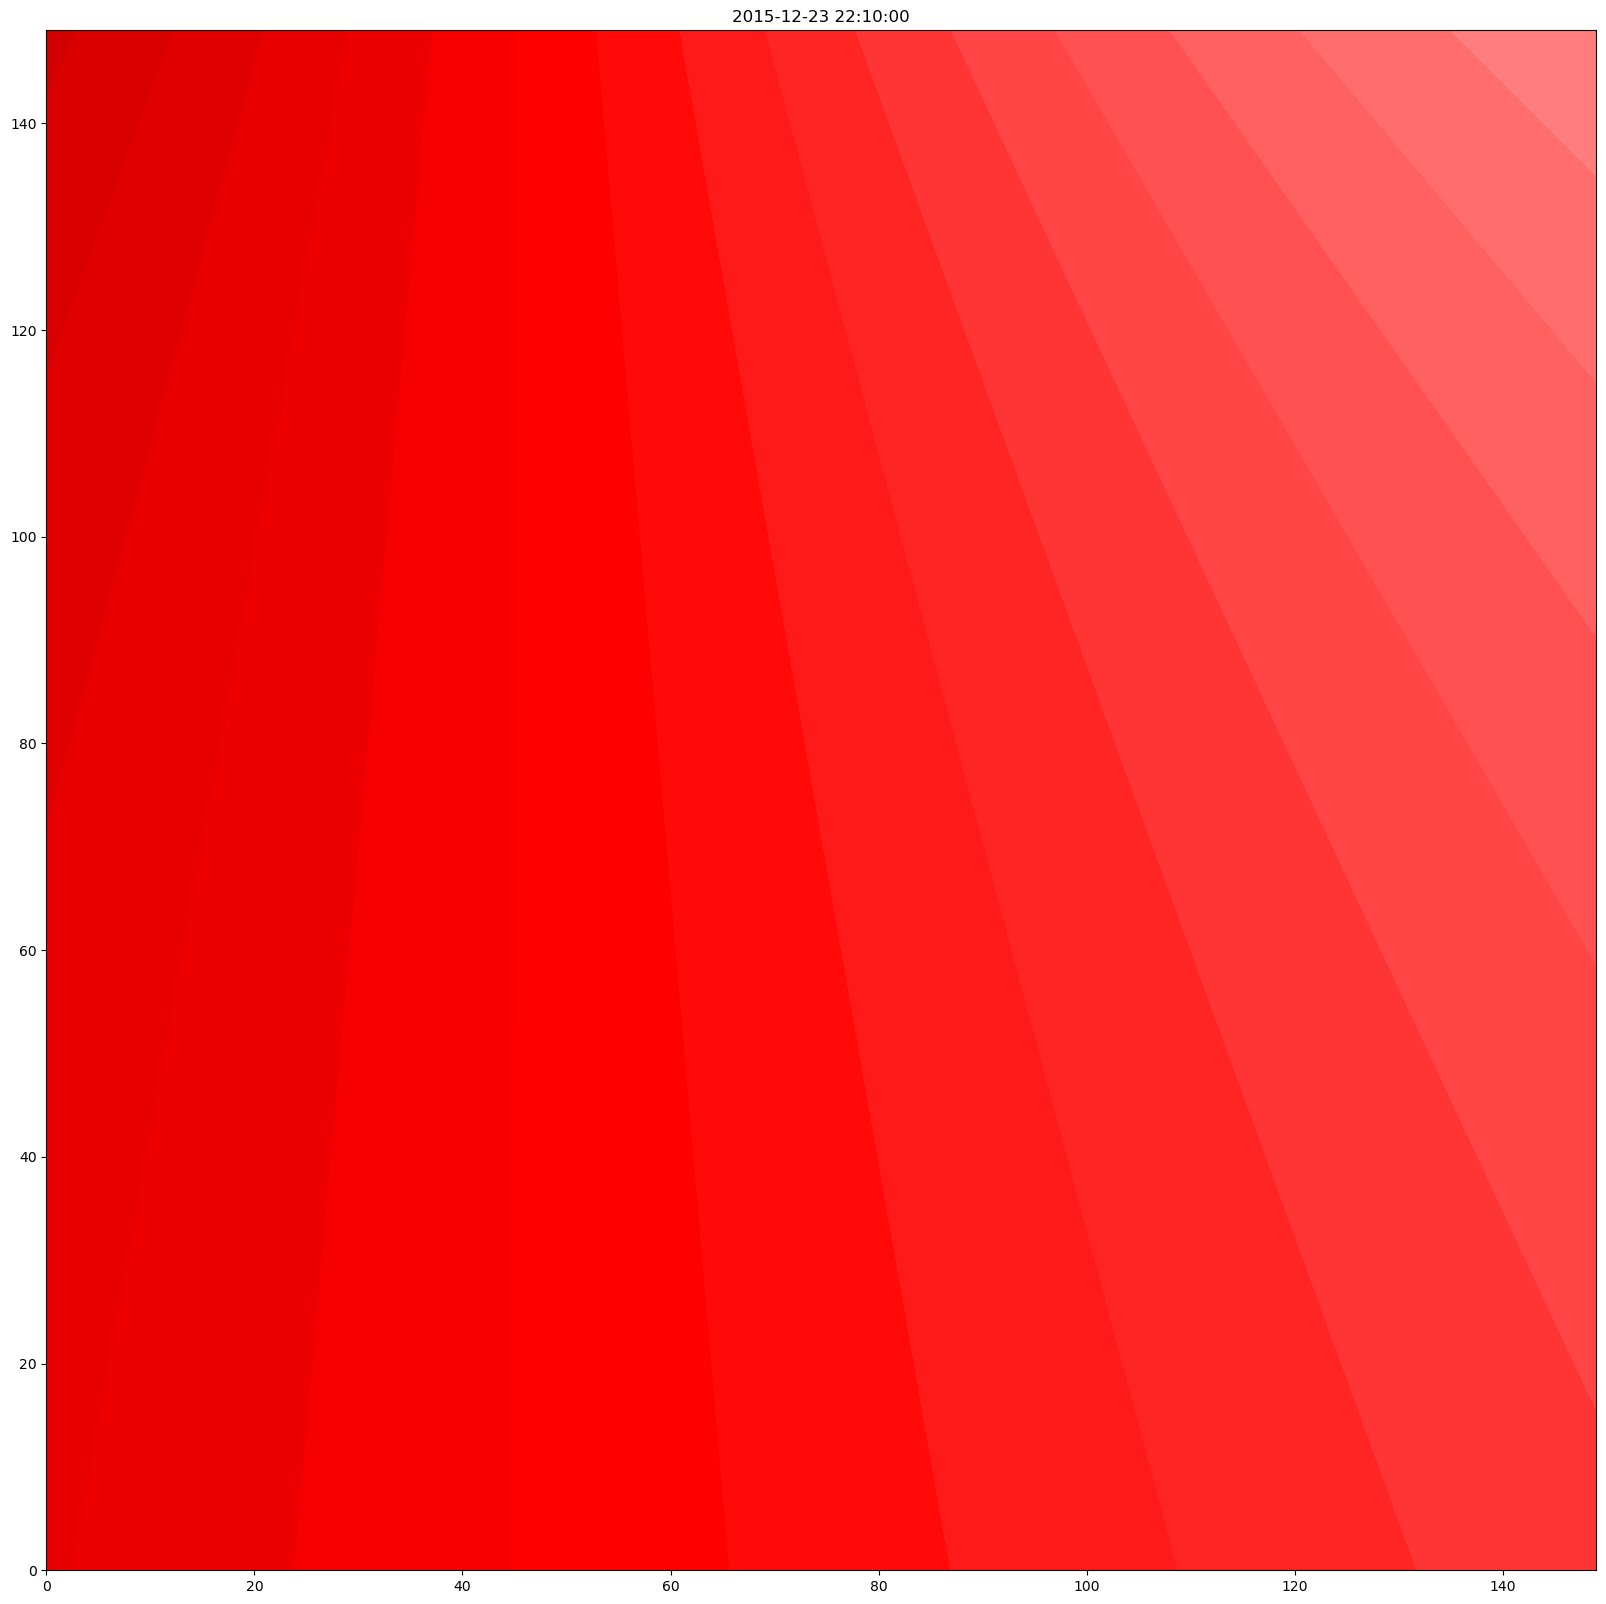

In [15]:
#time=8
lev=4
plt.figure(1, figsize=(20,20))
plt.contourf(xr,xr,azim2,np.arange(0,360,5),cmap=plt.cm.seismic)
#plt.contourf(xr,xr,distance_kdp_zdr[0],np.arange(-180,180,5),cmap=plt.cm.seismic)

#plt.contour(xr,xr,rot[lev,:,:],np.arange(0.002,0.010,0.002),colors='k')
#plt.contour(xr,xr,rot[lev,:,:],colors='k')

# plt.contour(xr,xr,rot[12,:,:],np.arange(0.002,0.010,0.002),colors='r')
# plt.contour(xr,xr,rot[20,:,:],np.arange(0.002,0.010,0.002),colors='b')
# plt.contour(xr,xr,rot[28,:,:],np.arange(0.002,0.010,0.002),colors='grey')

plt.title(str(datetime.fromtimestamp(times[0])))

In [16]:
print(np.min(azim))

220.80839317013692
